<a href="https://colab.research.google.com/github/willhjm/williamhenrique.github.io/blob/main/Atividade_Pr%C3%A1tica_UN2_Biblioteca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Gerenciamento de Livros

Este notebook implementa um sistema simples de gerenciamento de livros para uma biblioteca. Ele permitirá:

- Cadastrar novos livros
- Listar todos os livros disponíveis
- Buscar um livro pelo título
- Gerar um gráfico com a quantidade de livros por gênero

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# O pandas é usado para manipulação de dados
# O Matplotlib e o Seaborn são utilizados para a criação de gráficos

# Iniciando uma lista vazia
books_data = []

# Adicionando os livros iniciais
add_book("Dom Casmurro", "Machado de Assis", "Romance", 1899)
add_book("O Pequeno Príncipe", "Antoine de Saint-Exupéry", "Fábula", 1943)
add_book("Cem Anos de Solidão", "Gabriel García Márquez", "Realismo Mágico", 1967)
add_book("A Culpa é das Estrelas", "John Green", "Romance", 2012)
add_book("1984", "George Orwell", "Distopia", 1949)
add_book("Crime e Castigo", "Fiódor Dostoiévski", "Romance", 1866)
add_book("Duna", "Frank Herbert", "Ficção Científica", 1965)
add_book("O Senhor dos Anéis", "J.R.R. Tolkien", "Fantasia", 1954)
add_book("Frankenstein", "Mary Shelley", "Ficção Científica", 1818)


Livro 'Dom Casmurro' adicionado com sucesso!
Livro 'O Pequeno Príncipe' adicionado com sucesso!
Livro 'Cem Anos de Solidão' adicionado com sucesso!
Livro 'A Culpa é das Estrelas' adicionado com sucesso!
Livro '1984' adicionado com sucesso!
Livro 'Crime e Castigo' adicionado com sucesso!
Livro 'Duna' adicionado com sucesso!
Livro 'O Senhor dos Anéis' adicionado com sucesso!
Livro 'Frankenstein' adicionado com sucesso!


### 1. Cadastrar novos livros

In [21]:
# Definir função para cadastrar novos livros na lista "books_data"
def add_book(title, author, genre, year):
    book = {
        'title': title,
        'author': author,
        'genre': genre.title(), # Padroniza o gênero para Title Case
        'year': year
    }
    books_data.append(book)
    print(f"Livro '{title}' adicionado com sucesso!")




### 2. Listar todos os livros disponíveis

In [25]:
#definir uma função para caso não houvesse livros cadastrados ainda
def list_books():
    if not books_data:
        print("Nenhum livro cadastrado no sistema.")
        return

    df_books = pd.DataFrame(books_data)
    print("Livros disponíveis:")
    display(df_books)

# Exemplo de uso:
list_books()

Livros disponíveis:


,title,author,genre,year
0,Dom Casmurro,Machado de Assis,Romance,1899
1,O Pequeno Príncipe,Antoine de Saint-Exupéry,Fábula,1943
2,Cem Anos de Solidão,Gabriel García Márquez,Realismo Mágico,1967
3,A Culpa é das Estrelas,John Green,Romance,2012
4,1984,George Orwell,Distopia,1949
5,Crime e Castigo,Fiódor Dostoiévski,Romance,1866
6,Duna,Frank Herbert,Ficção Científica,1965
7,O Senhor dos Anéis,J.R.R. Tolkien,Fantasia,1954
8,Frankenstein,Mary Shelley,Ficção Científica,1818


### 3. Buscar um livro pelo título

In [27]:
import difflib
#A biblioteca difflib é um módulo nativo do Python usado principalmente para comparar sequências de dados (como textos, strings, listas e arquivos) e identificar as diferenças ou semelhanças entre elas

import re
#A biblioteca re do Python serve para trabalhar com expressões regulares (Regex), que são padrões usados para buscar, validar, extrair e manipular textos de forma rápida e avançada.

#Definindo a função para busca de livros por títulos
def search_book_by_title(title):
    if not books_data:
        print("Nenhum livro cadastrado para busca.")
        return

    df_books = pd.DataFrame(books_data)
    all_titles = df_books['title'].tolist()

    # Limpando a entrada para melhorar a comparação
    cleaned_title = re.sub(r'[^a-zA-Z0-9\s]', '', title).lower()
    cleaned_all_titles = [re.sub(r'[^a-zA-Z0-9\s]', '', t).lower() for t in all_titles]

    # Trazendo comparações próximas usando difflib em "cleaned_title" (título limpo)
    # 'n' como número máximo de comparação
    # A cutoff trás similiaridade de 60%.
    close_matches_cleaned = difflib.get_close_matches(cleaned_title, cleaned_all_titles, n=5, cutoff=0.6)

    if close_matches_cleaned:
        # Comparar combinações ao titulo original
        original_close_matches = []
        for cleaned_match in close_matches_cleaned:
            for i, original_t in enumerate(all_titles):
                if re.sub(r'[^a-zA-Z0-9\s]', '', original_t).lower() == cleaned_match:
                    original_close_matches.append(original_t)
                    break

        # Filtrar o DataFrame para incluir apenas a combinação mais próxima
        found_books = df_books[df_books['title'].isin(original_close_matches)]
        print(f"Livros encontrados (aproximação para '{title}'):")
        display(found_books)
    else:
        print(f"Nenhum livro encontrado com o título aproximado '{title}'.")


### 4. Gerar um gráfico com a quantidade de livros por gênero

In [28]:
def plot_books_by_genre():
    if not books_data:
        print("Nenhum livro cadastrado para gerar o gráfico.")
        return

    df_books = pd.DataFrame(books_data)
    genre_counts = df_books['genre'].value_counts()

    if genre_counts.empty:
        print("Não há dados de gênero para plotar.")
        return

    plt.figure(figsize=(5, 3))
    sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='viridis', legend=False)
    plt.title('Quantidade de Livros por Gênero')
    plt.xlabel('Gênero')
    plt.ylabel('Quantidade de Livros')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### 5. Menu Principal do Sistema de Gerenciamento de Livros


--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 4

--- GERAR GRÁFICO ---


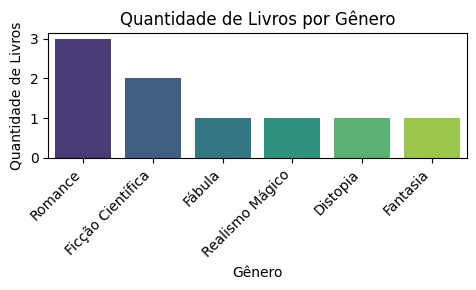


--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 2

--- LISTAR LIVROS ---
Livros disponíveis:


,title,author,genre,year
0,Dom Casmurro,Machado de Assis,Romance,1899
1,O Pequeno Príncipe,Antoine de Saint-Exupéry,Fábula,1943
2,Cem Anos de Solidão,Gabriel García Márquez,Realismo Mágico,1967
3,A Culpa é das Estrelas,John Green,Romance,2012
4,1984,George Orwell,Distopia,1949
5,Crime e Castigo,Fiódor Dostoiévski,Romance,1866
6,Duna,Frank Herbert,Ficção Científica,1965
7,O Senhor dos Anéis,J.R.R. Tolkien,Fantasia,1954
8,Frankenstein,Mary Shelley,Ficção Científica,1818



--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 3

--- BUSCAR LIVRO ---
Digite o título (ou parte dele) para buscar: senhor dos aneis
Livros encontrados (aproximação para 'senhor dos aneis'):


,title,author,genre,year
7,O Senhor dos Anéis,J.R.R. Tolkien,Fantasia,1954



--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 1

--- CADASTRAR NOVO LIVRO ---
Título: Memórias Póstumas de Brás Cubas
Autor: Machado de Assis
Gênero: Romance
Ano: 1881
Livro 'Memórias Póstumas de Brás Cubas' adicionado com sucesso!

--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 2

--- LISTAR LIVROS ---
Livros disponíveis:


,title,author,genre,year
0,Dom Casmurro,Machado de Assis,Romance,1899
1,O Pequeno Príncipe,Antoine de Saint-Exupéry,Fábula,1943
2,Cem Anos de Solidão,Gabriel García Márquez,Realismo Mágico,1967
3,A Culpa é das Estrelas,John Green,Romance,2012
4,1984,George Orwell,Distopia,1949
5,Crime e Castigo,Fiódor Dostoiévski,Romance,1866
6,Duna,Frank Herbert,Ficção Científica,1965
7,O Senhor dos Anéis,J.R.R. Tolkien,Fantasia,1954
8,Frankenstein,Mary Shelley,Ficção Científica,1818
9,Memórias Póstumas de Brás Cubas,Machado de Assis,Romance,1881



--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 3

--- BUSCAR LIVRO ---
Digite o título (ou parte dele) para buscar: pequeno principe
Livros encontrados (aproximação para 'pequeno principe'):


,title,author,genre,year
1,O Pequeno Príncipe,Antoine de Saint-Exupéry,Fábula,1943



--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 4

--- GERAR GRÁFICO ---


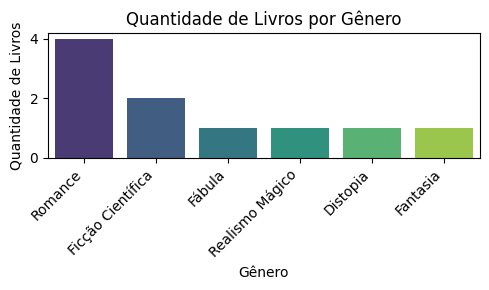


--- MENU PRINCIPAL ---
1. Cadastrar um novo livro
2. Listar todos os livros
3. Buscar livro pelo título
4. Gerar gráfico de livros por gênero
5. Sair
Escolha uma opção: 5
Saindo do sistema. Até mais!


In [29]:
def main_menu():
    while True:
        print("\n--- MENU PRINCIPAL ---")
        print("1. Cadastrar um novo livro")
        print("2. Listar todos os livros")
        print("3. Buscar livro pelo título")
        print("4. Gerar gráfico de livros por gênero")
        print("5. Sair")

        choice = input("Escolha uma opção: ")

        if choice == '1':
            print("\n--- CADASTRAR NOVO LIVRO ---")
            title = input("Título: ")
            author = input("Autor: ")
            genre = input("Gênero: ")
            year = int(input("Ano: ")) # Assumindo entrada de ano válida
            add_book(title, author, genre, year)
        elif choice == '2':
            print("\n--- LISTAR LIVROS ---")
            list_books()
        elif choice == '3':
            print("\n--- BUSCAR LIVRO ---")
            search_title = input("Digite o título (ou parte dele) para buscar: ")
            search_book_by_title(search_title)
        elif choice == '4':
            print("\n--- GERAR GRÁFICO ---")
            plot_books_by_genre()
        elif choice == '5':
            print("Saindo do sistema. Até mais!")
            break
        else:
            print("Opção inválida. Por favor, tente novamente.")

# Chama o menu principal para iniciar o sistema
main_menu()
